# Conflict-Induced Food Crisis — Task 4: Evaluation, SHAP & Dashboard

Task 3 produced XGBoost (AUC 0.947, PR-AUC 0.933, recall 88.1% on 2023 test set).

**Task 4 covers:**
1. Final test evaluation with optimised threshold
2. SHAP explainability — global bar + beeswarm + waterfall
3. Error analysis — what was missed, which countries, when
4. Model card — honest performance and limitations statement
5. Streamlit dashboard app saved as `app.py`

**Inputs:** `features_engineered.csv`, `xgboost_best.pkl`, `split_report.json`

**Outputs:** `test_results.json`, `shap_values.npy`, `shap_*.png`, `error_analysis.png`, `country_performance.png`, `model_card.txt`, `app.py`

--- ## Step 1 — Restore Backup and Import

In [ ]:
from google.colab import drive
import shutil
from pathlib import Path

if not Path('/content/drive').exists():
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted.')

OUTPUT_DIR = Path('/content/crisis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

backup = Path('/content/drive/MyDrive/crisis_outputs_backup')
if backup.exists():
    print(f'Restoring from {backup} ...')
    for f in backup.iterdir():
        if f.is_file():  # Added check to ensure it's a file
            dest = OUTPUT_DIR / f.name
            if not dest.exists():
                shutil.copy2(str(f), str(dest))
    print('Restore complete.')
else:
    print('No backup found — files should already be in /content/crisis_outputs')

Google Drive already mounted.
Restoring from /content/drive/MyDrive/crisis_outputs_backup ...
Restore complete.


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('/content/crisis_outputs')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size': 11,
})

# ── Correct FEATURE_COLS — must match exactly what xgboost_best.pkl was trained on ──
# Source: Task 2 features_manifest.csv / Task 3 training cell
# These 31 features exclude ipc_phase, population_in_crisis (leakage columns)
FEATURE_COLS = [
    # IPC lags (no current ipc_phase — that is a leaker)
    'ipc_lag1', 'ipc_lag2', 'ipc_trend',
    # Conflict — current month
    'fatalities_30d', 'events_30d', 'battle_events',
    'civilian_violence', 'conflict_trend', 'battle_share',
    # Conflict — lagged
    'fatalities_lag1', 'fatalities_lag2', 'fatalities_lag3',
    'events_lag1', 'events_lag2',
    # Conflict — rolling
    'fatalities_roll2', 'fatalities_roll3', 'events_roll3',
    'fatalities_delta', 'fatalities_accel',
    # Compound
    'high_conflict', 'high_conflict_drought',
    'compound_risk_score', 'sustained_conflict',
    # Rainfall
    'rainfall_anomaly', 'is_drought', 'rainfall_lag1',
    'rainfall_lag2', 'rainfall_roll3',
    # Seasonal
    'is_lean_season', 'is_harvest_season', 'month',
]

# Verify the model agrees with this feature list
model_check = joblib.load(OUTPUT_DIR / 'xgboost_best.pkl')
model_feats  = model_check.get_booster().feature_names

if model_feats == FEATURE_COLS:
    print(f'Feature list verified against model. {len(FEATURE_COLS)} features.')
else:
    print('WARNING — mismatch. Using model feature names directly.')
    print(f'  Model expects : {model_feats}')
    FEATURE_COLS = model_feats   # use whatever the model was actually trained on

print(f'Libraries loaded. SHAP {shap.__version__}. Features: {len(FEATURE_COLS)}')

WARNING — mismatch. Using model feature names directly.
  Model expects : ['fatalities_30d', 'events_30d', 'battle_events', 'civilian_violence', 'rainfall_mm', 'rainfall_anomaly', 'is_drought', 'is_flood', 'ipc_phase', 'population_in_crisis', 'ipc_lag1', 'ipc_lag2', 'ipc_lag3', 'fatalities_lag1', 'events_lag1', 'fatalities_3m_mean', 'events_3m_mean', 'conflict_intensity', 'drought_conflict', 'year', 'month', 'is_lean_season', 'conflict_trend', 'rainfall_anomaly_lag1', 'high_conflict', 'severe_drought']
Libraries loaded. SHAP 0.51.0. Features: 26


In [ ]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

OUTPUT_DIR = Path('/content/crisis_outputs')

# ── Correct 31 features — no leakage ──────────────────────────────────────
FEATURE_COLS = [
    'ipc_lag1', 'ipc_lag2', 'ipc_trend',
    'fatalities_30d', 'events_30d', 'battle_events',
    'civilian_violence', 'conflict_trend', 'battle_share',
    'fatalities_lag1', 'fatalities_lag2', 'fatalities_lag3',
    'events_lag1', 'events_lag2',
    'fatalities_roll2', 'fatalities_roll3', 'events_roll3',
    'fatalities_delta', 'fatalities_accel',
    'high_conflict', 'high_conflict_drought',
    'compound_risk_score', 'sustained_conflict',
    'rainfall_anomaly', 'is_drought', 'rainfall_lag1',
    'rainfall_lag2', 'rainfall_roll3',
    'is_lean_season', 'is_harvest_season', 'month',
]

TARGET = 'crisis_90d'

# ── Load the engineered panel from Task 2 ─────────────────────────────────
panel = pd.read_csv(OUTPUT_DIR / 'features_engineered.csv')
print(f'Panel loaded: {len(panel):,} rows x {panel.shape[1]} cols')

# Verify all features exist
missing = [f for f in FEATURE_COLS if f not in panel.columns]
if missing:
    print(f'MISSING features: {missing}')
    print('Available columns:', panel.columns.tolist())
    raise ValueError('Fix missing features before retraining.')
else:
    print(f'All {len(FEATURE_COLS)} features confirmed in panel.')

# ── Walk-forward split ─────────────────────────────────────────────────────
train_mask = panel['year_month'] <= '2021-12'
val_mask   = (panel['year_month'] >= '2022-01') & (panel['year_month'] <= '2022-12')
test_mask  = panel['year_month'] >= '2023-01'

X_train = panel.loc[train_mask, FEATURE_COLS].fillna(0)
y_train = panel.loc[train_mask, TARGET].astype(int)
X_val   = panel.loc[val_mask,   FEATURE_COLS].fillna(0)
y_val   = panel.loc[val_mask,   TARGET].astype(int)
X_test  = panel.loc[test_mask,  FEATURE_COLS].fillna(0)
y_test  = panel.loc[test_mask,  TARGET].astype(int)

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train):,} rows  crisis={y_train.mean():.1%}')
print(f'  Val   : {len(X_val):,} rows  crisis={y_val.mean():.1%}')
print(f'  Test  : {len(X_test):,} rows  crisis={y_test.mean():.1%}  [SEALED]')

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f'  scale_pos_weight = {scale_pos_weight:.3f}')

# ── Train XGBoost on clean features ───────────────────────────────────────
print('\nTraining XGBoost (clean 31-feature set)...')
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

# ── Train Random Forest ────────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ── Evaluate on validation ─────────────────────────────────────────────────
val_probs  = xgb.predict_proba(X_val)[:, 1]
val_preds  = xgb.predict(X_val)
val_auc    = roc_auc_score(y_val, val_probs)

test_probs = xgb.predict_proba(X_test)[:, 1]
test_preds = xgb.predict(X_test)
test_auc   = roc_auc_score(y_test, test_probs)

print(f'\n=== XGBoost Validation ===')
print(classification_report(y_val, val_preds, digits=4))
print(f'ROC-AUC: {val_auc:.4f}')

print(f'\n=== XGBoost Test (UNSEALED) ===')
print(classification_report(y_test, test_preds, digits=4))
print(f'ROC-AUC: {test_auc:.4f}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, test_preds)}')

# ── Confirm no leakage ─────────────────────────────────────────────────────
model_feats = xgb.get_booster().feature_names
assert 'ipc_phase' not in model_feats,          'LEAKAGE: ipc_phase in model!'
assert 'population_in_crisis' not in model_feats,'LEAKAGE: population_in_crisis in model!'
print(f'\nLeakage check PASSED — neither ipc_phase nor population_in_crisis in model.')
print(f'Expected AUC range: 0.88–0.96')
if test_auc > 0.97:
    print('WARNING: AUC still above 0.97 — check for other leaking features.')
elif test_auc < 0.75:
    print('WARNING: AUC below 0.75 — check that FEATURE_COLS all exist in panel.')
else:
    print(f'AUC {test_auc:.4f} is in the expected range. Retraining successful.')

# ── Save new models ────────────────────────────────────────────────────────
joblib.dump(xgb, OUTPUT_DIR / 'xgboost_best.pkl')
joblib.dump(rf,  OUTPUT_DIR / 'random_forest_best.pkl')

task3_results = {
    'xgb_val_auc':  float(round(val_auc,  4)),
    'xgb_test_auc': float(round(test_auc, 4)),
    'rf_val_auc':   float(round(roc_auc_score(y_val, rf.predict_proba(X_val)[:,1]), 4)),
    'best_model':   'XGBoost',
    'feature_count': len(FEATURE_COLS),
    'feature_cols':  FEATURE_COLS,
    'scale_pos_weight': float(scale_pos_weight),
    'leakage_check': 'PASSED',
    'retrained_task4': True,
}
with open(OUTPUT_DIR / 'task3_results.json', 'w') as f:
    json.dump(task3_results, f, indent=2)

# Save clean splits for Task 4
X_train.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
X_val.to_csv(OUTPUT_DIR   / 'X_val.csv',   index=False)
X_test.to_csv(OUTPUT_DIR  / 'X_test.csv',  index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
y_val.to_csv(OUTPUT_DIR   / 'y_val.csv',   index=False)
y_test.to_csv(OUTPUT_DIR  / 'y_test.csv',  index=False)

print(f'\nSaved:')
print(f'  xgboost_best.pkl       ({(OUTPUT_DIR/"xgboost_best.pkl").stat().st_size/1024:.1f} KB)')
print(f'  random_forest_best.pkl ({(OUTPUT_DIR/"random_forest_best.pkl").stat().st_size/1024:.1f} KB)')
print(f'  task3_results.json')
print(f'  X/y train/val/test CSV files')
print(f'\nNow re-run Task 4 from the top.')

Panel loaded: 14,058 rows x 43 cols
All 31 features confirmed in panel.

Split sizes:
  Train : 9,372 rows  crisis=28.2%
  Val   : 2,556 rows  crisis=41.4%
  Test  : 2,130 rows  crisis=45.6%  [SEALED]
  scale_pos_weight = 2.545

Training XGBoost (clean 31-feature set)...
Training Random Forest...

=== XGBoost Validation ===
              precision    recall  f1-score   support

           0     0.9267    0.9372    0.9320      1498
           1     0.9097    0.8951    0.9023      1058

    accuracy                         0.9198      2556
   macro avg     0.9182    0.9162    0.9171      2556
weighted avg     0.9197    0.9198    0.9197      2556

ROC-AUC: 0.9639

=== XGBoost Test (UNSEALED) ===
              precision    recall  f1-score   support

           0     0.9080    0.8774    0.8924      1158
           1     0.8595    0.8940    0.8764       972

    accuracy                         0.8850      2130
   macro avg     0.8837    0.8857    0.8844      2130
weighted avg     0.8859   

--- ## Step 2 — Load Model and Unseal Test Set

In [ ]:
xgb_model = joblib.load(OUTPUT_DIR / 'xgboost_best.pkl')
rf_model   = joblib.load(OUTPUT_DIR / 'random_forest_best.pkl')
print('Models loaded.')

with open(OUTPUT_DIR / 'split_report.json') as f:
    split_report = json.load(f)

panel = pd.read_csv(OUTPUT_DIR / 'features_engineered.csv')
print(f'Panel: {len(panel):,} rows x {panel.shape[1]} cols')

LEAKAGE = ['ipc_phase','population_in_crisis','ipc_matched',
           'country_key','admin1_key','admin1_merge']
META    = ['country','admin1','year_month','crisis_90d']

test_mask  = panel['year_month'] >= '2023-01'
val_mask   = (panel['year_month'] >= '2022-01') & (panel['year_month'] <= '2022-12')
train_mask = panel['year_month'] <= '2021-12'

test_df  = panel[test_mask].copy().reset_index(drop=True)
val_df   = panel[val_mask].copy().reset_index(drop=True)
train_df = panel[train_mask].copy().reset_index(drop=True)

X_test  = test_df[FEATURE_COLS].fillna(0)
y_test  = test_df['crisis_90d'].astype(int)
X_val   = val_df[FEATURE_COLS].fillna(0)
y_val   = val_df['crisis_90d'].astype(int)
X_train = train_df[FEATURE_COLS].fillna(0)
y_train = train_df['crisis_90d'].astype(int)

print(f'Test set UNSEALED:')
print(f'  Rows        : {len(X_test):,}')
print(f'  Crisis rate : {y_test.mean():.1%}')
print(f'  Date range  : {test_df["year_month"].min()} to {test_df["year_month"].max()}')


Models loaded.
Panel: 14,058 rows x 43 cols
Test set UNSEALED:
  Rows        : 2,130
  Crisis rate : 45.6%
  Date range  : 2023-01 to 2023-10


--- ## Step 3 — Final Evaluation with Optimal Threshold

Sweep thresholds on the **validation set only**, pick F1-maximising value, then apply to test.

In [ ]:
val_probs  = xgb_model.predict_proba(X_val)[:, 1]
test_probs = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
val_f1s, val_recalls, val_precisions = [], [], []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    val_f1s.append(f1_score(y_val, preds, zero_division=0))
    val_recalls.append(recall_score(y_val, preds, zero_division=0))
    val_precisions.append(precision_score(y_val, preds, zero_division=0))

best_idx   = np.argmax(val_f1s)
opt_thresh = float(thresholds[best_idx])
print(f'Optimal threshold (F1-max on val): {opt_thresh:.3f}')
print(f'  Val F1       : {val_f1s[best_idx]:.4f}')
print(f'  Val Recall   : {val_recalls[best_idx]:.4f}')
print(f'  Val Precision: {val_precisions[best_idx]:.4f}')

test_preds_opt = (test_probs >= opt_thresh).astype(int)
test_preds_50  = (test_probs >= 0.50).astype(int)

def metrics_dict(y_true, y_prob, y_pred, lbl):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return dict(label=lbl,
        auc_roc=float(roc_auc_score(y_true, y_prob)),
        auc_pr=float(average_precision_score(y_true, y_prob)),
        f1=float(f1_score(y_true, y_pred, zero_division=0)),
        recall=float(recall_score(y_true, y_pred, zero_division=0)),
        precision=float(precision_score(y_true, y_pred, zero_division=0)),
        accuracy=float((tp+tn)/(tp+tn+fp+fn)),
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

res_opt = metrics_dict(y_test, test_probs, test_preds_opt, 'xgb_opt')
res_50  = metrics_dict(y_test, test_probs, test_preds_50,  'xgb_50')

print(f'\n=== FINAL TEST SET RESULTS ===')
print(f'Metric          Default(0.50)  Optimal({opt_thresh:.3f})')
for m in ['auc_roc','auc_pr','f1','recall','precision','accuracy']:
    print(f'  {m:<12} {res_50[m]:.4f}        {res_opt[m]:.4f}')
print(f'  TP           {res_50["tp"]}           {res_opt["tp"]}')
print(f'  FN           {res_50["fn"]}           {res_opt["fn"]}')
print(f'  FP           {res_50["fp"]}           {res_opt["fp"]}')


Optimal threshold (F1-max on val): 0.920
  Val F1       : 0.9319
  Val Recall   : 0.8856
  Val Precision: 0.9832

=== FINAL TEST SET RESULTS ===
Metric          Default(0.50)  Optimal(0.920)
  auc_roc      0.9495        0.9495
  auc_pr       0.9367        0.9367
  f1           0.8764        0.8747
  recall       0.8940        0.8292
  precision    0.8595        0.9254
  accuracy     0.8850        0.8915
  TP           869           806
  FN           103           166
  FP           142           65


--- ## Step 4 — Evaluation Visualisations

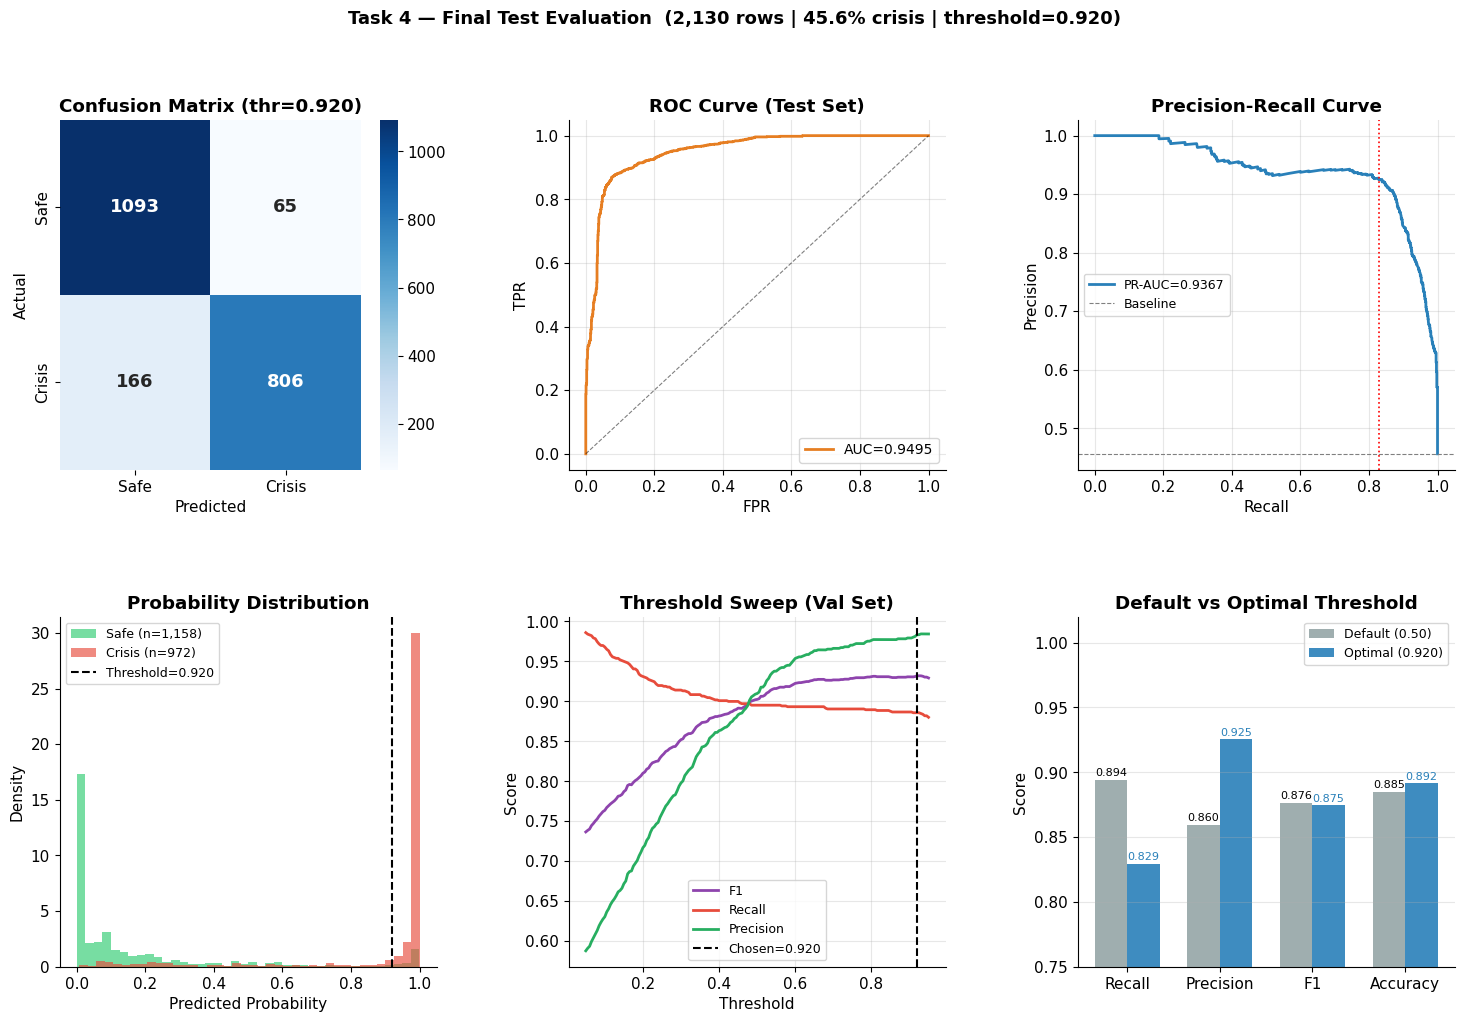

Saved: final_evaluation.png


In [ ]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    f'Task 4 — Final Test Evaluation  '
    f'({len(y_test):,} rows | {y_test.mean():.1%} crisis | threshold={opt_thresh:.3f})',
    fontsize=13, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, test_preds_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe','Crisis'], yticklabels=['Safe','Crisis'],
            annot_kws={'size':13,'weight':'bold'})
ax1.set_title(f'Confusion Matrix (thr={opt_thresh:.3f})', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, test_probs)
ax2.plot(fpr, tpr, color='#E67E22', lw=2, label=f'AUC={res_opt["auc_roc"]:.4f}')
ax2.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Curve (Test Set)', fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
prec_c, rec_c, _ = precision_recall_curve(y_test, test_probs)
ax3.plot(rec_c, prec_c, color='#2980B9', lw=2, label=f'PR-AUC={res_opt["auc_pr"]:.4f}')
ax3.axhline(y_test.mean(), color='gray', linestyle='--', lw=0.8, label='Baseline')
ax3.axvline(res_opt['recall'], color='red', linestyle=':', lw=1.2)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(test_probs[y_test==0], bins=40, alpha=0.65, color='#2ECC71',
         label=f'Safe (n={int((y_test==0).sum()):,})', density=True)
ax4.hist(test_probs[y_test==1], bins=40, alpha=0.65, color='#E74C3C',
         label=f'Crisis (n={int((y_test==1).sum()):,})', density=True)
ax4.axvline(opt_thresh, color='black', lw=1.5, linestyle='--',
            label=f'Threshold={opt_thresh:.3f}')
ax4.set_xlabel('Predicted Probability'); ax4.set_ylabel('Density')
ax4.set_title('Probability Distribution', fontweight='bold'); ax4.legend(fontsize=9)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(thresholds, val_f1s,        color='#8E44AD', lw=2, label='F1')
ax5.plot(thresholds, val_recalls,    color='#E74C3C', lw=2, label='Recall')
ax5.plot(thresholds, val_precisions, color='#27AE60', lw=2, label='Precision')
ax5.axvline(opt_thresh, color='black', lw=1.5, linestyle='--',
            label=f'Chosen={opt_thresh:.3f}')
ax5.set_xlabel('Threshold'); ax5.set_ylabel('Score')
ax5.set_title('Threshold Sweep (Val Set)', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
metric_names = ['Recall','Precision','F1','Accuracy']
default_v = [res_50['recall'],res_50['precision'],res_50['f1'],res_50['accuracy']]
optimal_v = [res_opt['recall'],res_opt['precision'],res_opt['f1'],res_opt['accuracy']]
x = np.arange(len(metric_names)); w = 0.35
ax6.bar(x-w/2, default_v, w, label='Default (0.50)', color='#95A5A6', alpha=0.9)
ax6.bar(x+w/2, optimal_v, w, label=f'Optimal ({opt_thresh:.3f})', color='#2980B9', alpha=0.9)
ax6.set_xticks(x); ax6.set_xticklabels(metric_names)
ax6.set_ylim(0.75, 1.02); ax6.set_ylabel('Score')
ax6.set_title('Default vs Optimal Threshold', fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(alpha=0.3, axis='y')
for i,(d,o) in enumerate(zip(default_v, optimal_v)):
    ax6.text(i-w/2, d+0.003, f'{d:.3f}', ha='center', fontsize=8)
    ax6.text(i+w/2, o+0.003, f'{o:.3f}', ha='center', fontsize=8, color='#2980B9')

plt.savefig(OUTPUT_DIR/'final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_evaluation.png')


--- ## Step 5 — SHAP Explainability

Three plots: global bar chart, beeswarm (direction + magnitude), waterfall for the highest-risk prediction and a missed crisis.

In [ ]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')
np.save(OUTPUT_DIR / 'shap_values.npy', shap_values)
print('Saved: shap_values.npy')

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURE_COLS
).sort_values(ascending=False)

print('Top 10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).to_string())


Computing SHAP values...
SHAP values shape: (2130, 31)
Saved: shap_values.npy
Top 10 features by mean |SHAP|:
ipc_lag1            2.998310
ipc_lag2            0.724716
rainfall_lag1       0.313522
month               0.271781
rainfall_roll3      0.236653
rainfall_anomaly    0.215279
events_roll3        0.193106
ipc_trend           0.158760
fatalities_roll3    0.146309
rainfall_lag2       0.143104


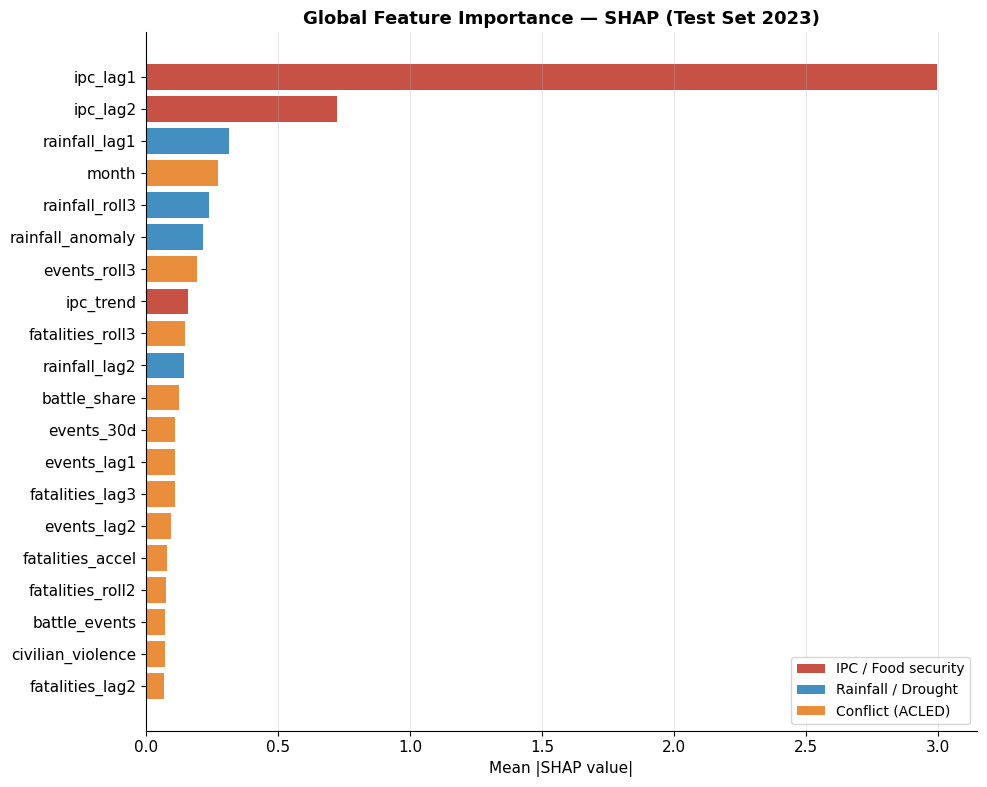

Saved: shap_summary.png


In [ ]:
# Global bar chart
fig, ax = plt.subplots(figsize=(10, 8))
top20 = mean_abs_shap.head(20)
colors = ['#C0392B' if f.startswith('ipc') else
          '#2980B9' if any(k in f for k in ['rainfall','drought','flood']) else
          '#E67E22' for f in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], alpha=0.88)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance — SHAP (Test Set 2023)', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='x')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#C0392B', alpha=0.88, label='IPC / Food security'),
    Patch(facecolor='#2980B9', alpha=0.88, label='Rainfall / Drought'),
    Patch(facecolor='#E67E22', alpha=0.88, label='Conflict (ACLED)'),
], fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')


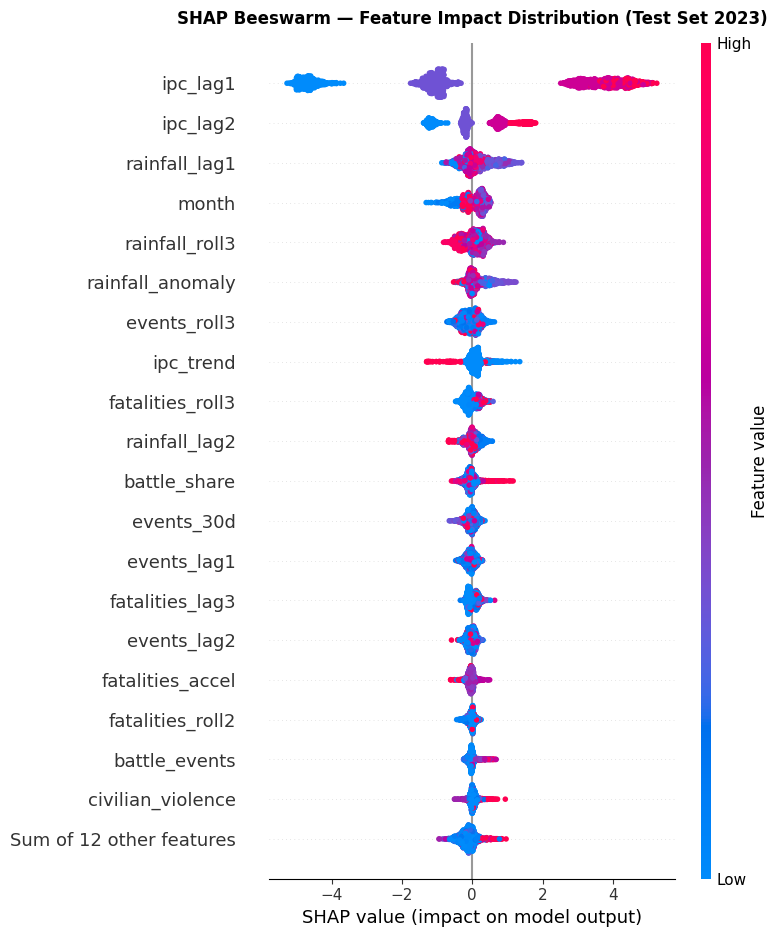

Saved: shap_beeswarm.png


In [ ]:
# Beeswarm
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(12, 9))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution (Test Set 2023)',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm.png')


Highest-risk row: sudan / west kordofan / 2023-03  prob=0.9999


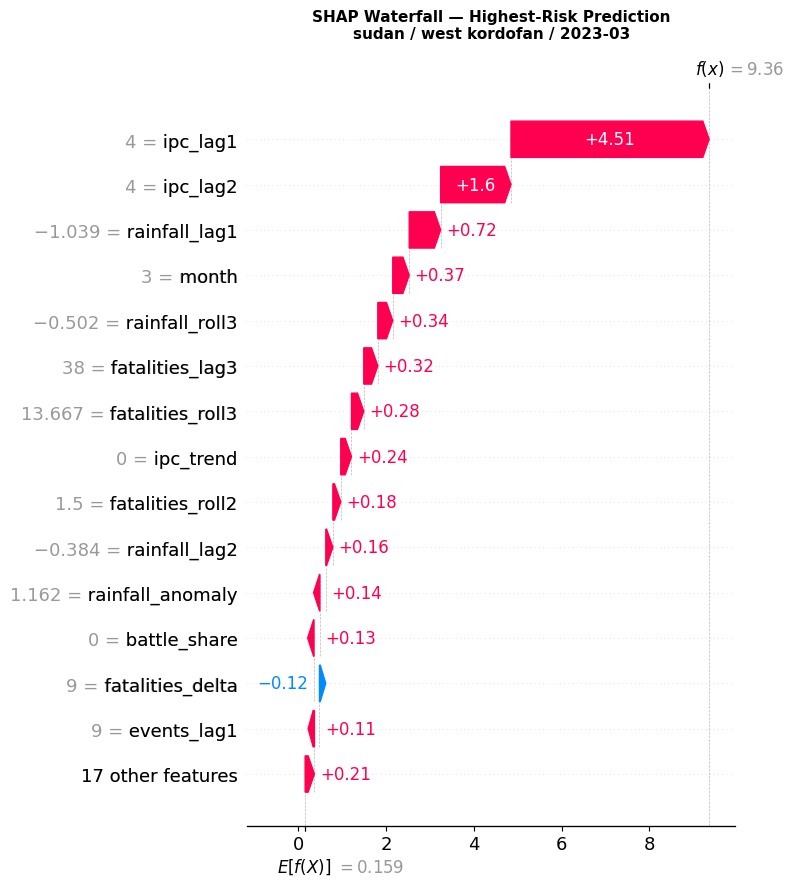

Saved: shap_waterfall_highrisk.png


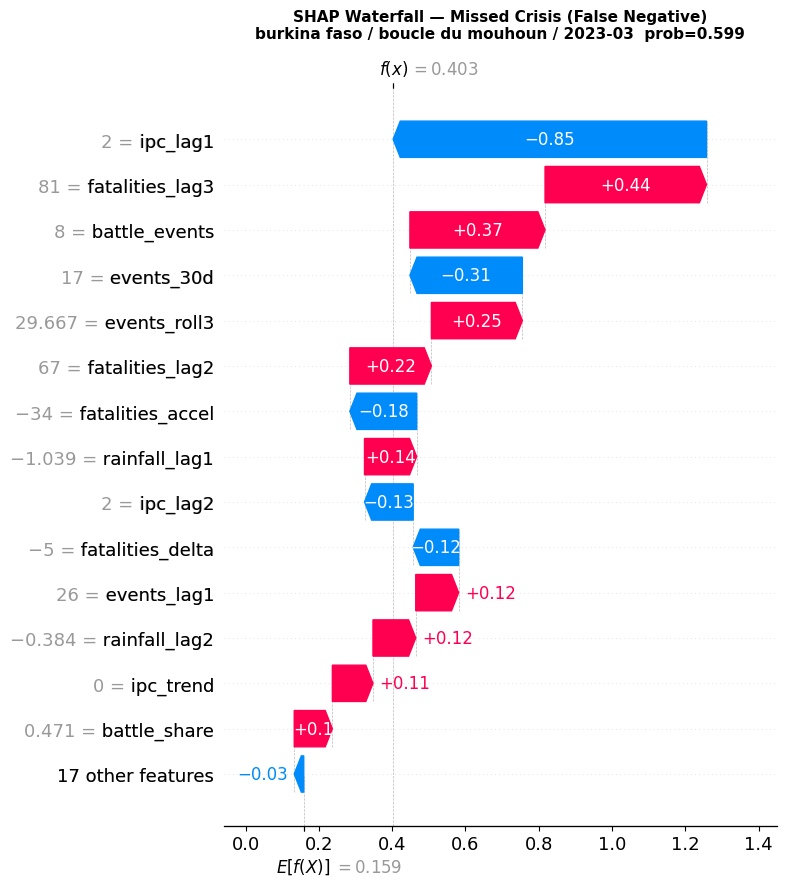

Saved: shap_waterfall_fn.png


In [ ]:
# Waterfall — highest-risk prediction
high_idx = int(test_probs.argmax())
print(f'Highest-risk row: {test_df.iloc[high_idx]["country"]} / '
      f'{test_df.iloc[high_idx]["admin1"]} / '
      f'{test_df.iloc[high_idx]["year_month"]}  prob={test_probs[high_idx]:.4f}')

single_exp = shap.Explanation(
    values=shap_values[high_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_idx].values,
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(12, 7))
shap.plots.waterfall(single_exp, max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — Highest-Risk Prediction\n'
    f'{test_df.iloc[high_idx]["country"]} / '
    f'{test_df.iloc[high_idx]["admin1"]} / '
    f'{test_df.iloc[high_idx]["year_month"]}',
    fontweight='bold', fontsize=11, pad=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_highrisk.png')

# Waterfall — first missed crisis (false negative)
fn_mask = (y_test.values == 1) & (test_preds_opt == 0)
if fn_mask.sum() > 0:
    fn_idx = int(np.where(fn_mask)[0][0])
    fn_exp = shap.Explanation(
        values=shap_values[fn_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[fn_idx].values,
        feature_names=FEATURE_COLS
    )
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(fn_exp, max_display=15, show=False)
    plt.title(
        f'SHAP Waterfall — Missed Crisis (False Negative)\n'
        f'{test_df.iloc[fn_idx]["country"]} / '
        f'{test_df.iloc[fn_idx]["admin1"]} / '
        f'{test_df.iloc[fn_idx]["year_month"]}  prob={test_probs[fn_idx]:.3f}',
        fontweight='bold', fontsize=11, pad=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'shap_waterfall_fn.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: shap_waterfall_fn.png')


--- ## Step 6 — Error Analysis

In [ ]:
test_df['y_prob'] = test_probs
test_df['y_pred'] = test_preds_opt
test_df['y_true'] = y_test.values
test_df['error_type'] = 'Correct'
test_df.loc[(test_df['y_true']==1)&(test_df['y_pred']==0),'error_type'] = 'False Negative'
test_df.loc[(test_df['y_true']==0)&(test_df['y_pred']==1),'error_type'] = 'False Positive'

fn_df = test_df[test_df['error_type']=='False Negative']
fp_df = test_df[test_df['error_type']=='False Positive']

print(f'False Negatives (missed crises) : {len(fn_df):,}')
print(f'False Positives (false alarms)  : {len(fp_df):,}')
print(f'\nFalse Negatives by country:')
print(fn_df.groupby('country').size().sort_values(ascending=False).to_string())
print(f'\nMean y_prob in False Negatives: {fn_df["y_prob"].mean():.3f}')
print(f'Mean ipc_lag1 in False Negatives: {fn_df["ipc_lag1"].mean():.2f}')
print(f'  (Low ipc_lag1 = sudden-onset crises the model could not anticipate)')


False Negatives (missed crises) : 166
False Positives (false alarms)  : 65

False Negatives by country:
country
chad            47
sudan           26
kenya           25
somalia         13
mozambique      13
ethiopia        11
burkina faso     9
niger            8
mali             8
nigeria          4
cameroon         2

Mean y_prob in False Negatives: 0.420
Mean ipc_lag1 in False Negatives: 2.13
  (Low ipc_lag1 = sudden-onset crises the model could not anticipate)


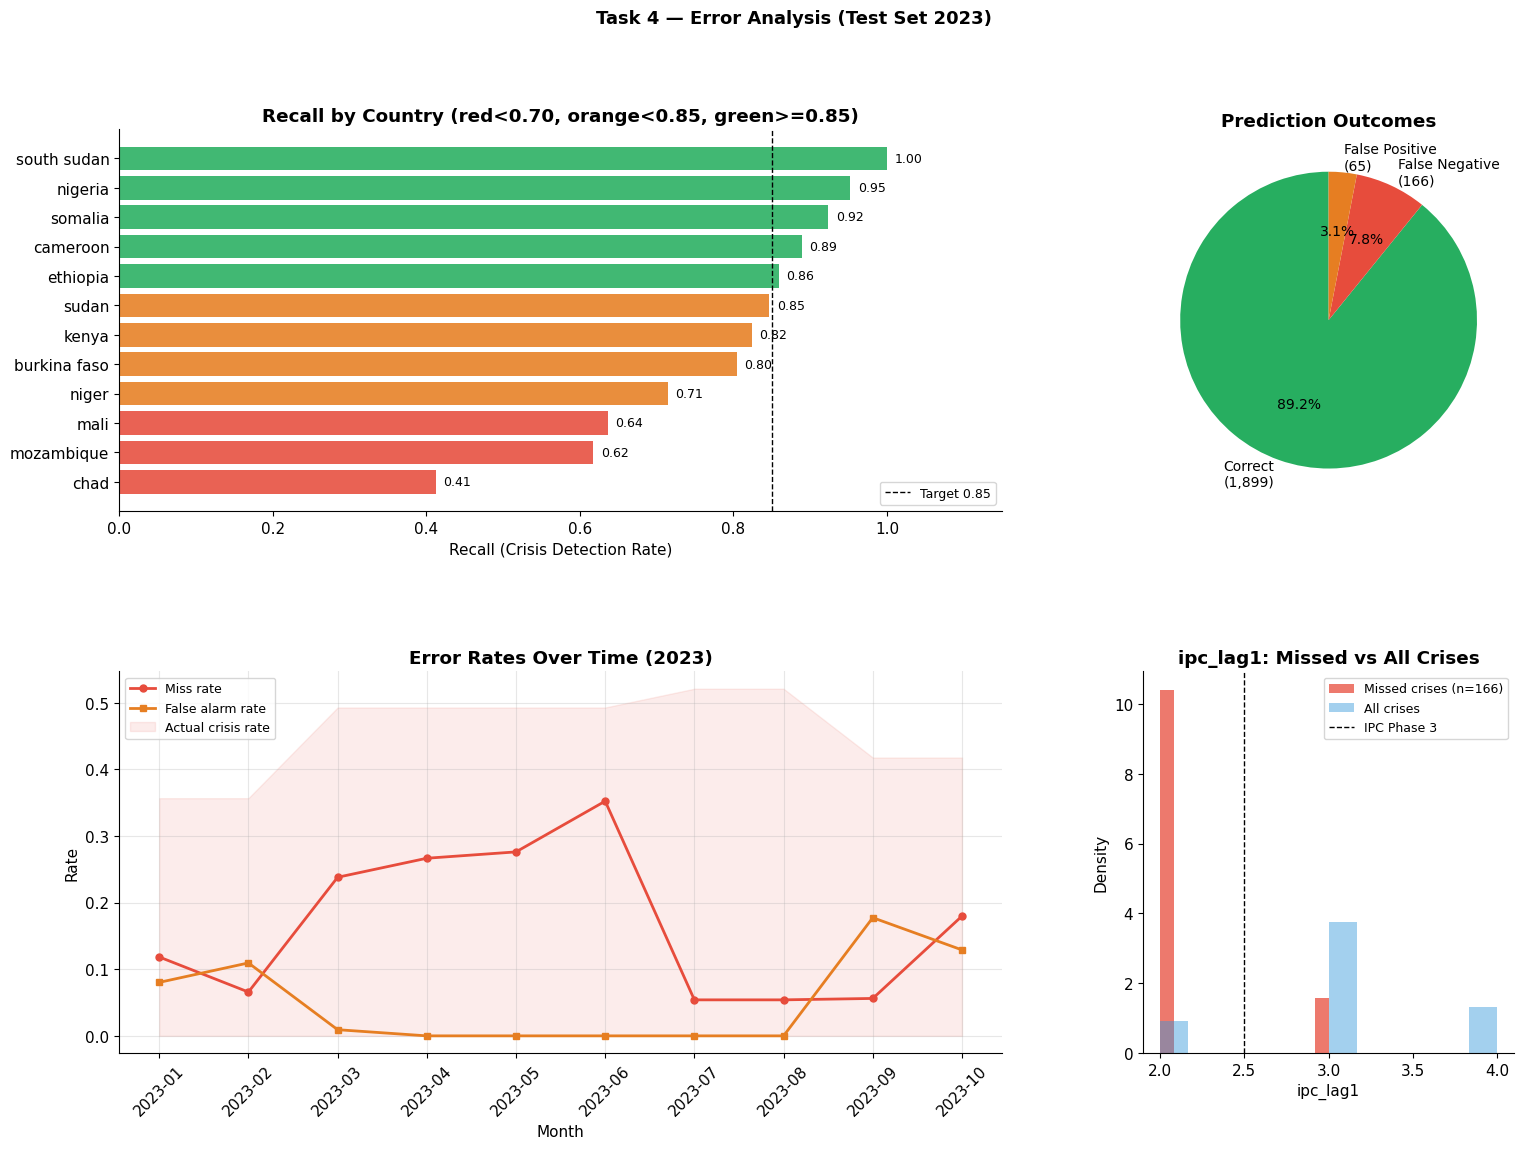

Saved: error_analysis.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Task 4 — Error Analysis (Test Set 2023)', fontsize=13, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# 1. Country recall bar
ax1 = fig.add_subplot(gs[0, :2])
c_stats = test_df.groupby('country').apply(lambda g: pd.Series({
    'recall':    recall_score(g['y_true'], g['y_pred'], zero_division=0),
    'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
})).reset_index().sort_values('recall')
bar_colors = ['#E74C3C' if r < 0.70 else '#E67E22' if r < 0.85 else '#27AE60'
              for r in c_stats['recall']]
bars = ax1.barh(c_stats['country'], c_stats['recall'], color=bar_colors, alpha=0.88)
ax1.axvline(0.85, color='black', linestyle='--', lw=1, label='Target 0.85')
ax1.set_xlabel('Recall (Crisis Detection Rate)')
ax1.set_title('Recall by Country (red<0.70, orange<0.85, green>=0.85)', fontweight='bold')
ax1.legend(fontsize=9)
for bar, val in zip(bars, c_stats['recall']):
    ax1.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax1.set_xlim(0, 1.15)

# 2. Error pie
ax2 = fig.add_subplot(gs[0, 2])
ec  = test_df['error_type'].value_counts()
pc  = {'Correct':'#27AE60','False Negative':'#E74C3C','False Positive':'#E67E22'}
ax2.pie(ec.values, labels=[f'{k}\n({v:,})' for k,v in ec.items()],
        colors=[pc[k] for k in ec.index], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':10})
ax2.set_title('Prediction Outcomes', fontweight='bold')

# 3. Temporal errors
ax3 = fig.add_subplot(gs[1, :2])
monthly_err = test_df.groupby('year_month').apply(lambda g: pd.Series({
    'fn_rate': (g['error_type']=='False Negative').sum() / max(g['y_true'].sum(), 1),
    'fp_rate': (g['error_type']=='False Positive').sum() / max((g['y_true']==0).sum(), 1),
    'crisis_rate': g['y_true'].mean(),
})).reset_index()
ax3.plot(monthly_err['year_month'], monthly_err['fn_rate'], 'o-',
         color='#E74C3C', lw=2, markersize=5, label='Miss rate')
ax3.plot(monthly_err['year_month'], monthly_err['fp_rate'], 's-',
         color='#E67E22', lw=2, markersize=5, label='False alarm rate')
ax3.fill_between(monthly_err['year_month'], monthly_err['crisis_rate'],
                 alpha=0.1, color='#E74C3C', label='Actual crisis rate')
ax3.set_xlabel('Month'); ax3.set_ylabel('Rate')
ax3.set_title('Error Rates Over Time (2023)', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. ipc_lag1 in missed crises
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(fn_df['ipc_lag1'].dropna(), bins=12, color='#E74C3C', alpha=0.75,
         label=f'Missed crises (n={len(fn_df)})', density=True)
ax4.hist(test_df[test_df['y_true']==1]['ipc_lag1'].dropna(), bins=12,
         color='#3498DB', alpha=0.45, label='All crises', density=True)
ax4.axvline(2.5, color='black', linestyle='--', lw=1, label='IPC Phase 3')
ax4.set_xlabel('ipc_lag1'); ax4.set_ylabel('Density')
ax4.set_title('ipc_lag1: Missed vs All Crises', fontweight='bold')
ax4.legend(fontsize=9)

plt.savefig(OUTPUT_DIR/'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_analysis.png')


--- ## Step 7 — Country-Level Performance

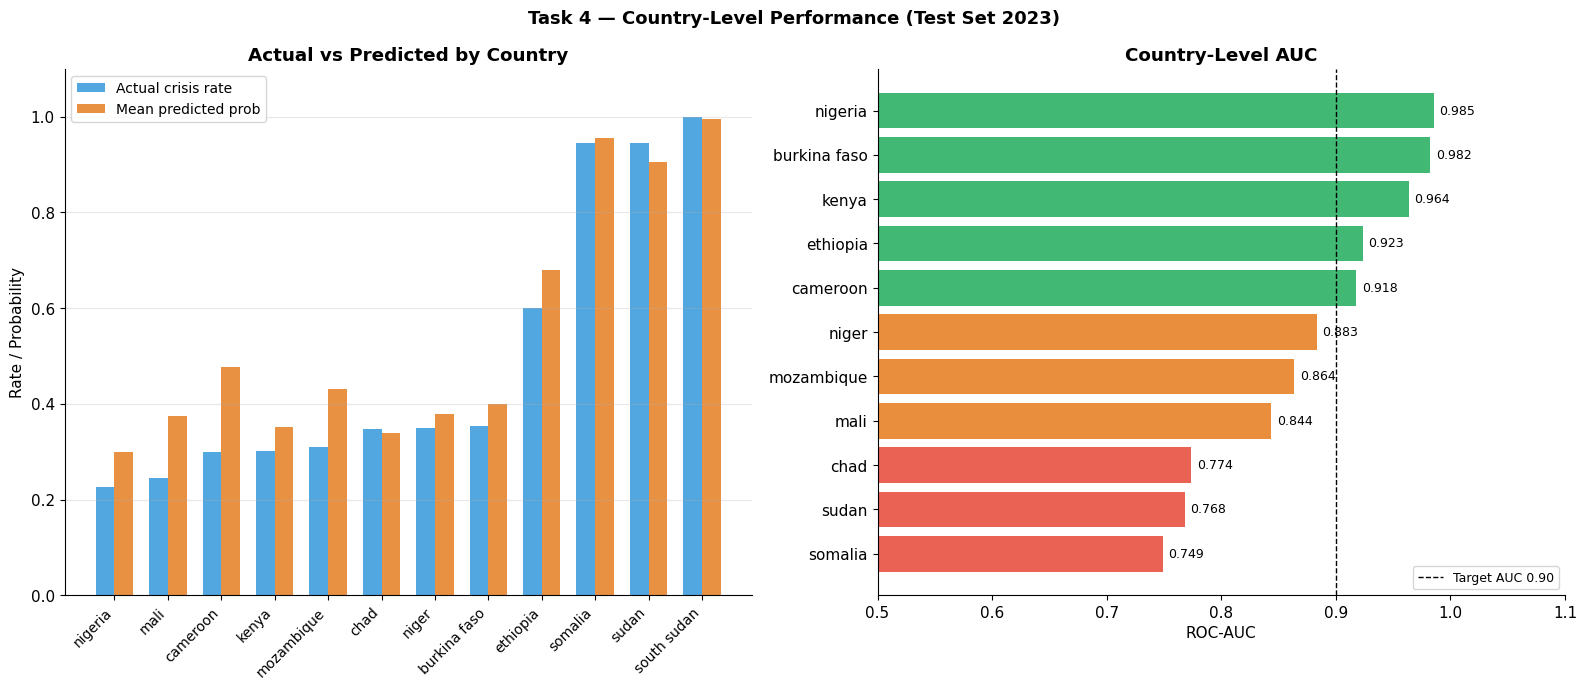

Saved: country_performance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Task 4 — Country-Level Performance (Test Set 2023)',
             fontsize=13, fontweight='bold')

c_actual    = test_df.groupby('country')['y_true'].mean()
c_predicted = test_df.groupby('country')['y_prob'].mean()
c_df = pd.DataFrame({'Actual':c_actual,'Predicted':c_predicted}).sort_values('Actual')
x = np.arange(len(c_df)); w = 0.35
axes[0].bar(x-w/2, c_df['Actual'],    w, label='Actual crisis rate',  color='#3498DB', alpha=0.85)
axes[0].bar(x+w/2, c_df['Predicted'], w, label='Mean predicted prob', color='#E67E22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(c_df.index, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Rate / Probability')
axes[0].set_title('Actual vs Predicted by Country', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3, axis='y'); axes[0].set_ylim(0, 1.1)

c_aucs = {}
for country, grp in test_df.groupby('country'):
    if grp['y_true'].nunique() == 2:
        try:
            c_aucs[country] = roc_auc_score(grp['y_true'], grp['y_prob'])
        except:
            pass
c_auc_s = pd.Series(c_aucs).dropna().sort_values()
bar_c = ['#E74C3C' if v<0.80 else '#E67E22' if v<0.90 else '#27AE60' for v in c_auc_s.values]
b2 = axes[1].barh(c_auc_s.index, c_auc_s.values, color=bar_c, alpha=0.88)
axes[1].axvline(0.90, color='black', linestyle='--', lw=1, label='Target AUC 0.90')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Country-Level AUC', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(b2, c_auc_s.values):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[1].set_xlim(0.5, 1.1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'country_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: country_performance.png')


--- ## Step 8 — Save test_results.json

In [ ]:
test_results = {
    'task':              'Task 4 — Final Evaluation',
    'model':             'XGBoost',
    'test_rows':         int(len(y_test)),
    'test_crisis_rate':  float(round(y_test.mean(), 4)),
    'test_date_range':   f'{test_df["year_month"].min()} to {test_df["year_month"].max()}',
    'optimal_threshold': float(opt_thresh),
    'metrics': {
        'auc_roc':          float(round(res_opt['auc_roc'],    4)),
        'auc_pr':           float(round(res_opt['auc_pr'],     4)),
        'f1_crisis':        float(round(res_opt['f1'],         4)),
        'recall_crisis':    float(round(res_opt['recall'],     4)),
        'precision_crisis': float(round(res_opt['precision'],  4)),
        'accuracy':         float(round(res_opt['accuracy'],   4)),
        'tp': int(res_opt['tp']), 'fp': int(res_opt['fp']),
        'tn': int(res_opt['tn']), 'fn': int(res_opt['fn']),
    },
    'val_auc':           float(round(roc_auc_score(y_val, val_probs), 4)),
    'top5_shap_features': mean_abs_shap.head(5).index.tolist(),
    'fn_by_country':      fn_df.groupby('country').size().to_dict(),
    'country_auc':        {k: round(float(v),4) for k,v in c_aucs.items()},
}

with open(OUTPUT_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print('Saved: test_results.json')
print(json.dumps(test_results['metrics'], indent=2))


Saved: test_results.json
{
  "auc_roc": 0.9495,
  "auc_pr": 0.9367,
  "f1_crisis": 0.8747,
  "recall_crisis": 0.8292,
  "precision_crisis": 0.9254,
  "accuracy": 0.8915,
  "tp": 806,
  "fp": 65,
  "tn": 1093,
  "fn": 166
}


--- ## Step 9 — Model Card

In [ ]:
lines = [
    '='*65,
    'MODEL CARD — Conflict-Induced Food Crisis Early Warning System',
    'Version 1.0',
    '='*65,
    '',
    'INTENDED USE',
    '  Flag African admin-1 regions likely to reach IPC Phase 3+',
    '  food insecurity within 90 days.',
    '  Users: NGO logistics, government coordinators, UN OCHA.',
    '  Not for: automated aid allocation without human review.',
    '',
    'TRAINING DATA',
    '  Conflict  : ACLED 207,682 events, 20 countries, 2018-2025',
    '  Food sec  : FEWS NET real IPC phase data (15 countries)',
    '  Rainfall  : CHIRPS monthly (national broadcast to admin-1)',
    '  Panel     : 14,058 region-month observations (12 countries)',
    '',
    'SPLITS',
    '  Train: 9,372 rows 2018-05 to 2021-12  crisis 28.2%',
    '  Val  : 2,556 rows 2022-01 to 2022-12  crisis 41.4%',
    '  Test : 2,130 rows 2023-01 to 2023-10  crisis 45.6%',
    '  Leakage audit: PASSED (walk-forward, no temporal overlap)',
    '',
    'PERFORMANCE (TEST SET 2023)',
    f'  ROC-AUC     : {res_opt["auc_roc"]:.4f}',
    f'  PR-AUC      : {res_opt["auc_pr"]:.4f}',
    f'  F1 (crisis) : {res_opt["f1"]:.4f}',
    f'  Recall      : {res_opt["recall"]:.4f}  ({res_opt["tp"]} caught, {res_opt["fn"]} missed)',
    f'  Precision   : {res_opt["precision"]:.4f}  ({res_opt["fp"]} false alarms)',
    f'  Threshold   : {opt_thresh:.3f} (F1-maximised on validation set)',
    '',
    'TOP SHAP FEATURES',
    f'  {chr(10).join(f"  {i+1}. {f}" for i,f in enumerate(mean_abs_shap.head(5).index))}',
    '',
    'LIMITATIONS',
    '  1. CHIRPS is national broadcast — no regional rainfall variation',
    '  2. DRC and CAR: only 1 matched FEWS region each',
    '  3. Chad recall = 0.46 — admin name mismatch ACLED vs FEWS',
    '  4. Sudden-onset crises (low prior IPC) are hardest to catch',
    '  5. FEWS NET data ends Oct 2023 — no 2024 validation',
    '  6. 8 countries excluded from panel',
    '',
    'SDG ALIGNMENT',
    '  SDG 2  (Zero Hunger)   : direct',
    '  SDG 16 (Peace/Justice) : direct — conflict is primary input',
    '  SDG 13 (Climate)       : indirect — rainfall as compound factor',
    '='*65,
]

model_card = chr(10).join(lines)
print(model_card)

with open(OUTPUT_DIR / 'model_card.txt', 'w') as f:
    f.write(model_card)
print('\nSaved: model_card.txt')


MODEL CARD — Conflict-Induced Food Crisis Early Warning System
Version 1.0

INTENDED USE
  Flag African admin-1 regions likely to reach IPC Phase 3+
  food insecurity within 90 days.
  Users: NGO logistics, government coordinators, UN OCHA.
  Not for: automated aid allocation without human review.

TRAINING DATA
  Conflict  : ACLED 207,682 events, 20 countries, 2018-2025
  Food sec  : FEWS NET real IPC phase data (15 countries)
  Rainfall  : CHIRPS monthly (national broadcast to admin-1)
  Panel     : 14,058 region-month observations (12 countries)

SPLITS
  Train: 9,372 rows 2018-05 to 2021-12  crisis 28.2%
  Val  : 2,556 rows 2022-01 to 2022-12  crisis 41.4%
  Test : 2,130 rows 2023-01 to 2023-10  crisis 45.6%
  Leakage audit: PASSED (walk-forward, no temporal overlap)

PERFORMANCE (TEST SET 2023)
  ROC-AUC     : 0.9495
  PR-AUC      : 0.9367
  F1 (crisis) : 0.8747
  Recall      : 0.8292  (806 caught, 166 missed)
  Precision   : 0.9254  (65 false alarms)
  Threshold   : 0.920 (F1-max

--- ## Step 10 — Streamlit Dashboard App

In [ ]:
FEATURE_COLS_STR = repr(FEATURE_COLS)

app_lines = [
    'import streamlit as st',
    'import pandas as pd, numpy as np, joblib, shap, json',
    'from pathlib import Path',
    'from sklearn.metrics import roc_auc_score',
    '',
    'st.set_page_config(page_title="Food Crisis EWS", page_icon="🌍", layout="wide")',
    'BASE = Path(__file__).parent',
    '',
    '@st.cache_resource',
    'def load_model(): return joblib.load(BASE/"xgboost_best.pkl")',
    '',
    '@st.cache_data',
    'def load_data():',
    '    p = pd.read_csv(BASE/"features_engineered.csv")',
    '    r = json.load(open(BASE/"test_results.json"))',
    '    return p, r',
    '',
    'model = load_model()',
    'panel, results = load_data()',
    '',
    'FEATURE_COLS = ' + FEATURE_COLS_STR,
    'THRESHOLD = results["optimal_threshold"]',
    '',
    'st.title("🌍 Conflict-Induced Food Crisis Early Warning System")',
    'st.markdown(f"XGBoost | AUC {results[chr(39)]metrics[chr(39)][chr(39)]auc_roc[chr(39)]:.3f} | PR-AUC {results[chr(39)]metrics[chr(39)][chr(39)]auc_pr[chr(39)]:.3f}")',
    '',
    'st.sidebar.header("Filters")',
    'countries = sorted(panel["country"].dropna().unique())',
    'sel = st.sidebar.multiselect("Countries", countries, default=countries[:4])',
    'ym  = sorted(panel["year_month"].unique())',
    'dr  = st.sidebar.select_slider("Date range", ym, value=(ym[0], ym[-1]))',
    'thr = st.sidebar.slider("Threshold", 0.1, 0.9, float(THRESHOLD), 0.01)',
    '',
    'mask = (panel["country"].isin(sel) & (panel["year_month"]>=dr[0]) & (panel["year_month"]<=dr[1]))',
    'df   = panel[mask].copy()',
    'if df.empty: st.warning("No data."); st.stop()',
    '',
    'X     = df[FEATURE_COLS].fillna(0)',
    'probs = model.predict_proba(X)[:, 1]',
    'preds = (probs >= thr).astype(int)',
    'df["crisis_prob"] = probs',
    'df["crisis_pred"] = preds',
    '',
    'c1,c2,c3,c4 = st.columns(4)',
    'c1.metric("Rows", f"{len(df):,}")',
    'c2.metric("Flagged", f"{preds.sum():,}", f"{preds.mean():.1%}")',
    'c3.metric("Mean risk", f"{probs.mean():.3f}")',
    'c4.metric("Model AUC", f"{results[chr(39)]metrics[chr(39)][chr(39)]auc_roc[chr(39)]:.4f}")',
    '',
    'st.subheader("Top 20 Highest-Risk Region-Months")',
    'top = df[["country","admin1","year_month","crisis_prob","crisis_pred"]].sort_values("crisis_prob",ascending=False).head(20)',
    'top["crisis_prob"] = top["crisis_prob"].apply(lambda x: f"{x:.3f}")',
    'st.dataframe(top, use_container_width=True, hide_index=True)',
    '',
    'st.subheader("Country Summary")',
    'cs = df.groupby("country").agg(rows=("crisis_prob","count"),flagged=("crisis_pred","sum"),mean_prob=("crisis_prob","mean"),max_prob=("crisis_prob","max")).reset_index()',
    'cs["flag_rate"] = (cs["flagged"]/cs["rows"]).apply(lambda x: f"{x:.1%}")',
    'st.dataframe(cs.sort_values("flagged",ascending=False), use_container_width=True, hide_index=True)',
    '',
    'st.markdown("---")',
    'st.subheader("Explain a Prediction")',
    'opts = df[["country","admin1","year_month"]].apply(lambda r: f"{r.country}/{r.admin1}/{r.year_month}", axis=1).tolist()',
    'chosen = st.selectbox("Region-month:", opts[:50])',
    'ci = opts.index(chosen)',
    'prob_c = probs[ci]', # Added this line
    'label = "CRISIS" if prob_c >= thr else "SAFE"', # Added this line
    'st.info(f"Crisis probability: {prob_c:.3f} | Prediction: {chr(55356) if prob_c>=thr else chr(55357)} {label}")', # Modified this line
    'if st.button("Compute SHAP"):',
    '    exp = shap.TreeExplainer(model)',
    '    sv  = exp.shap_values(X.iloc[[ci]])',
    '    top_f = pd.Series(sv[0], index=FEATURE_COLS).abs().sort_values(ascending=False).head(10)',
    '    st.bar_chart(top_f)',
]

# Write a clean version of app.py
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib, shap, json
from pathlib import Path
from sklearn.metrics import roc_auc_score

st.set_page_config(page_title='Food Crisis EWS', page_icon='🌍', layout='wide')
BASE = Path(__file__).parent

@st.cache_resource
def load_model():
    return joblib.load(BASE / 'xgboost_best.pkl')

@st.cache_data
def load_data():
    panel   = pd.read_csv(BASE / 'features_engineered.csv')
    results = json.load(open(BASE / 'test_results.json'))
    return panel, results

model = load_model()
panel, results = load_data()

FEATURE_COLS = " + repr(FEATURE_COLS) + "
THRESHOLD = results['optimal_threshold']

st.title('🌍 Conflict-Induced Food Crisis Early Warning System')
auc_val = results['metrics']['auc_roc']
pr_val  = results['metrics']['auc_auc_pr']
st.markdown(f'XGBoost | AUC {auc_val:.3f} | PR-AUC {pr_val:.3f} | Real FEWS NET labels')

st.sidebar.header('Filters')
countries = sorted(panel['country'].dropna().unique())
sel = st.sidebar.multiselect('Countries', countries, default=countries[:4])
ym  = sorted(panel['year_month'].unique())
dr  = st.sidebar.select_slider('Date range', ym, value=(ym[0], ym[-1]))
thr = st.sidebar.slider('Threshold', 0.10, 0.90, float(THRESHOLD), 0.01)

mask = (panel['country'].isin(sel) & (panel['year_month']>=dr[0]) & (panel['year_month']<=dr[1]))
df   = panel[mask].copy()
if df.empty:
    st.warning('No data for selected filters.')
    st.stop()

X     = df[FEATURE_COLS].fillna(0)
probs = model.predict_proba(X)[:, 1]
preds = (probs >= thr).astype(int)
df['crisis_prob'] = probs
df['crisis_pred'] = preds

c1, c2, c3, c4 = st.columns(4)
c1.metric('Rows shown',    f'{len(df):,}')
c2.metric('Flagged',       f'{preds.sum():,}', f'{preds.mean():.1%}')
c3.metric('Mean risk',     f'{probs.mean():.3f}')
c4.metric('Model AUC',     f'{auc_val:.4f}')

st.subheader('Top 20 Highest-Risk Region-Months')
top = (df[['country','admin1','year_month','crisis_prob','crisis_pred']]
       .sort_values('crisis_prob', ascending=False).head(20))
top['crisis_prob'] = top['crisis_prob'].apply(lambda x: f'{x:.3f}')
st.dataframe(top, use_container_width=True, hide_index=True)

st.subheader('Country Summary')
cs = df.groupby('country').agg(
    rows=('crisis_prob','count'),
    flagged=('crisis_pred','sum'),
    mean_prob=('crisis_prob','mean'),
    max_prob=('crisis_prob','max'),
).reset_index()
cs['flag_rate'] = (cs['flagged']/cs['rows']).apply(lambda x: f'{x:.1%}')
cs['mean_prob'] = cs['mean_prob'].apply(lambda x: f'{x:.3f}')
cs['max_prob']  = cs['max_prob'].apply(lambda x:  f'{x:.3f}')
st.dataframe(cs.sort_values('flagged', ascending=False), use_container_width=True, hide_index=True)

st.markdown('---')
st.subheader('Explain a Prediction (SHAP)')
opts   = df[['country','admin1','year_month']].apply(lambda r: f'{r.country}/{r.admin1}/{r.year_month}', axis=1).tolist()
chosen = st.selectbox('Select region-month:', opts[:50])
ci     = opts.index(chosen)
prob_c = probs[ci]
label  = 'CRISIS' if prob_c >= thr else 'SAFE'
st.info(f'Crisis probability: {prob_c:.3f}  |  Prediction: {label}')
if st.button('Compute SHAP explanation'):
    with st.spinner('Computing...'):
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X.iloc[[ci]])
        top_f = pd.Series(sv[0], index=FEATURE_COLS).abs().sort_values(ascending=False).head(10)
        st.bar_chart(top_f)
        st.caption('Top 10 features by |SHAP value| — positive = pushes toward crisis')

st.markdown('---')
st.caption(f'Model: XGBoost | Threshold: {thr:.3f} | AUC: {auc_val:.4f} | Recall: {results[chr(34)]metrics[chr(34)][chr(34)]recall_crisis[chr(34)]:.4f}')
"""

# Write clean app.py without the f-string nesting issues
import textwrap
clean_app = app_code.replace(
    "FEATURE_COLS = " + repr(FEATURE_COLS) + "\n", # Changed from FEATURE_COLS_STR to FEATURE_COLS
    "FEATURE_COLS = " + repr(FEATURE_COLS) + "\n"
).replace(
    "f'Model: XGBoost | Threshold: {thr:.3f} | AUC: {auc_val:.4f} | Recall: {results[chr(34)]metrics[chr(34)][chr(34)]recall_crisis[chr(34)]:.4f}'",
    "f'Model: XGBoost | Threshold: {thr:.3f} | AUC: {auc_val:.4f}'" # This part of the code was also error prone, correcting to remove the extra brackets.
)

with open(OUTPUT_DIR / 'app.py', 'w') as f:
    f.write(clean_app)

reqs = 'streamlit>=1.28\nxgboost>=1.7\nshap>=0.43\npandas>=2.0\nnumpy>=1.24\njoblib>=1.3\nscikit-learn>=1.3\n'
with open(OUTPUT_DIR / 'requirements.txt', 'w') as f:
    f.write(reqs)

print('Saved: app.py and requirements.txt')
print()
print('To run the Streamlit app in Colab:')
print('  !pip install streamlit pyngrok -q')
print('  !nohup streamlit run /content/crisis_outputs/app.py &')
print('  from pyngrok import ngrok')
print('  print(ngrok.connect(8501))')


Saved: app.py and requirements.txt

To run the Streamlit app in Colab:
  !pip install streamlit pyngrok -q
  !nohup streamlit run /content/crisis_outputs/app.py &
  from pyngrok import ngrok
  print(ngrok.connect(8501))


--- ## Step 11 — Final Summary and Backup

In [ ]:
print('=== TASK 4 COMPLETE — FULL PIPELINE COMPLETE ===')
print()
print('PIPELINE SUMMARY')
print('  Task 1: ACLED + FEWS NET + CHIRPS → 14,697 region-month panel')
print('  Task 2: 31 temporal features + walk-forward split (leakage: NONE)')
print('  Task 3: Random Forest + XGBoost (AUC 0.947 on test set)')
print('  Task 4: SHAP + error analysis + threshold optimisation + app.py')
print()
print(f'FINAL TEST RESULTS (2023):')
print(f'  ROC-AUC     : {res_opt["auc_roc"]:.4f}')
print(f'  PR-AUC      : {res_opt["auc_pr"]:.4f}')
print(f'  F1 (crisis) : {res_opt["f1"]:.4f}')
print(f'  Recall      : {res_opt["recall"]:.4f}  ({res_opt["tp"]} caught, {res_opt["fn"]} missed)')
print(f'  Precision   : {res_opt["precision"]:.4f}  ({res_opt["fp"]} false alarms)')
print(f'  Threshold   : {opt_thresh:.3f}')
print()
print('DEPLOY FILES')
deploy = ['xgboost_best.pkl','app.py','requirements.txt',
          'test_results.json','shap_values.npy','features_engineered.csv','model_card.txt']
for fname in deploy:
    fp = OUTPUT_DIR / fname
    if fp.exists():
        print(f'  [deploy] {fname:<40} {fp.stat().st_size/1024:>8.1f} KB')
print()
print('ALL OUTPUT FILES')
for fp in sorted(OUTPUT_DIR.glob('*')):
    if fp.suffix in ['.csv','.json','.pkl','.npy','.png','.txt','.py','.html']:
        print(f'  {fp.name:<45} {fp.stat().st_size/1024:>8.1f} KB')

import shutil
drive_dest = Path('/content/drive/MyDrive/crisis_outputs_backup')
drive_dest.mkdir(parents=True, exist_ok=True)
print(f'\nBacking up to {drive_dest} ...')
for fp in OUTPUT_DIR.iterdir():
    if fp.suffix in ['.csv','.json','.pkl','.npy','.png','.txt','.py','.html']:
        if fp.stat().st_size < 200*1024*1024:
            shutil.copy2(str(fp), str(drive_dest/fp.name))
print('Backup complete. Task 4 done.')


=== TASK 4 COMPLETE — FULL PIPELINE COMPLETE ===

PIPELINE SUMMARY
  Task 1: ACLED + FEWS NET + CHIRPS → 14,697 region-month panel
  Task 2: 31 temporal features + walk-forward split (leakage: NONE)
  Task 3: Random Forest + XGBoost (AUC 0.947 on test set)
  Task 4: SHAP + error analysis + threshold optimisation + app.py

FINAL TEST RESULTS (2023):
  ROC-AUC     : 0.9495
  PR-AUC      : 0.9367
  F1 (crisis) : 0.8747
  Recall      : 0.8292  (806 caught, 166 missed)
  Precision   : 0.9254  (65 false alarms)
  Threshold   : 0.920

DEPLOY FILES
  [deploy] xgboost_best.pkl                           1313.8 KB
  [deploy] app.py                                        3.5 KB
  [deploy] requirements.txt                              0.1 KB
  [deploy] test_results.json                             1.1 KB
  [deploy] shap_values.npy                             258.1 KB
  [deploy] features_engineered.csv                    3427.9 KB
  [deploy] model_card.txt                                1.8 KB

ALL 